In [52]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.config import file_config

df_results = pd.read_csv(f"{file_config.results_dir}/predictions_rolling_pretrained_ensemble.csv")
print(df_results.head())


   actual  tft_pred  tft_lower  tft_upper  corrected_median  corrected_upper  \
0     0.0       0.0        0.0   0.020628               0.0              0.0   
1     0.0       0.0        0.0   0.021101               0.0              0.0   
2     0.0       0.0        0.0   0.019691               0.0              0.0   
3     0.0       0.0        0.0   0.020213               0.0              0.0   
4     0.0       0.0        0.0   0.020306               0.0              0.0   

   corrected_lower  correction  daylight        date                 time  \
0              0.0    0.008732         0  2023-01-11  2023-01-11 00:00:00   
1              0.0   -0.028669         0  2023-01-11  2023-01-11 01:00:00   
2              0.0   -0.031442         0  2023-01-11  2023-01-11 02:00:00   
3              0.0    0.002645         0  2023-01-11  2023-01-11 03:00:00   
4              0.0   -0.028649         0  2023-01-11  2023-01-11 04:00:00   

   naive  arima_pred  
0    0.0    0.000013  
1    0.0  

Residual error variance: 0.0225
ARIMA error variance:    0.0207
Residual: bias=0.0003 variance=0.0225 RMSE=0.1501
ARIMA:    bias=0.0586 variance=0.0207 RMSE=0.1553
Residual: p95=0.2953 p99=0.4022 excess_kurtosis=0.1825
ARIMA:    p95=0.3173 p99=0.4491 excess_kurtosis=1.4007


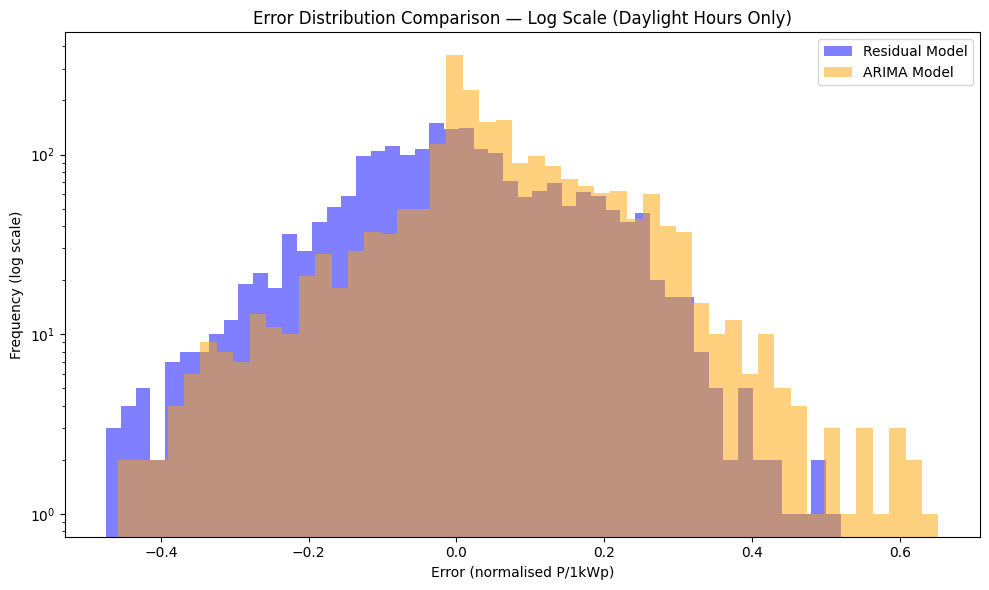

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kurtosis
# filter to daylight hours only
daylight_mask = df_results["daylight"] == 1

residual_errors = (
    df_results.loc[daylight_mask, "actual"] - 
    df_results.loc[daylight_mask, "corrected_median"]
)
arima_errors = (
    df_results.loc[daylight_mask, "actual"] - 
    df_results.loc[daylight_mask, "arima_pred"]
)

plt.figure(figsize=(10, 6))
plt.hist(residual_errors, bins=50, alpha=0.5, color="blue", label="Residual Model")
plt.hist(arima_errors, bins=50, alpha=0.5, color="orange", label="ARIMA Model")
plt.yscale("log")
plt.xlabel("Error (normalised P/1kWp)")
plt.ylabel("Frequency (log scale)")
plt.title("Error Distribution Comparison — Log Scale (Daylight Hours Only)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{file_config.results_dir}/error_distribution_daylight_log.png", dpi=300)
mask = df_results["daylight"] == 1

res_var   = (df_results.loc[mask, "actual"] - df_results.loc[mask, "corrected_median"]).var()
arima_var = (df_results.loc[mask, "actual"] - df_results.loc[mask, "arima_pred"]).var()

print(f"Residual error variance: {res_var:.4f}")
print(f"ARIMA error variance:    {arima_var:.4f}")
res_bias   = (df_results.loc[mask, "actual"] - df_results.loc[mask, "corrected_median"]).mean()
arima_bias = (df_results.loc[mask, "actual"] - df_results.loc[mask, "arima_pred"]).mean()

res_rmse   = np.sqrt(((df_results.loc[mask, "actual"] - df_results.loc[mask, "corrected_median"])**2).mean())
arima_rmse = np.sqrt(((df_results.loc[mask, "actual"] - df_results.loc[mask, "arima_pred"])**2).mean())

print(f"Residual: bias={res_bias:.4f} variance={res_var:.4f} RMSE={res_rmse:.4f}")
print(f"ARIMA:    bias={arima_bias:.4f} variance={arima_var:.4f} RMSE={arima_rmse:.4f}")

res_p95, res_p99   = np.percentile(np.abs(residual_errors), [95, 99])
arima_p95, arima_p99 = np.percentile(np.abs(arima_errors), [95, 99])

res_kurt   = kurtosis(residual_errors)      # excess kurtosis, normal = 0
arima_kurt = kurtosis(arima_errors)

print(f"Residual: p95={res_p95:.4f} p99={res_p99:.4f} excess_kurtosis={res_kurt:.4f}")
print(f"ARIMA:    p95={arima_p95:.4f} p99={arima_p99:.4f} excess_kurtosis={arima_kurt:.4f}")

Residual error variance: 0.0150
ARIMA error variance:    0.0140
Residual: bias=-0.0055 variance=0.0150 RMSE=0.1226
ARIMA:    bias=0.0466 variance=0.0140 RMSE=0.1272


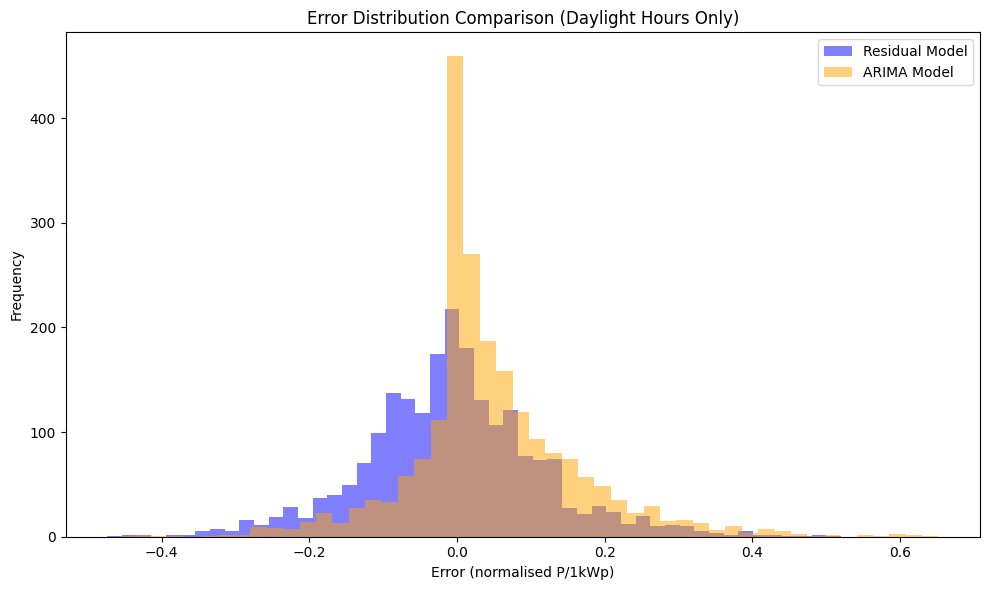

In [54]:
import matplotlib.pyplot as plt
import numpy as np
# filter to daylight hours only
results  = pd.read_csv(f"{file_config.results_dir}/predictions_rolling_pretrained_shaded_ensemble.csv")
daylight_mask = results["daylight"] == 1

residual_errors = (
    results.loc[daylight_mask, "actual"] - 
    results.loc[daylight_mask, "corrected_median"]
)
arima_errors = (
    results.loc[daylight_mask, "actual"] - 
    results.loc[daylight_mask, "arima_pred"]
)

plt.figure(figsize=(10, 6))
plt.hist(residual_errors, bins=50, alpha=0.5, 
         color="blue", label="Residual Model")
plt.hist(arima_errors, bins=50, alpha=0.5, 
         color="orange", label="ARIMA Model")
plt.xlabel("Error (normalised P/1kWp)")
plt.ylabel("Frequency")
plt.title("Error Distribution Comparison (Daylight Hours Only)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{file_config.results_dir}/error_distribution_daylight_shaded.png", dpi=300)

mask = results["daylight"] == 1

res_var   = (results.loc[mask, "actual"] - results.loc[mask, "corrected_median"]).var()
arima_var = (results.loc[mask, "actual"] - results.loc[mask, "arima_pred"]).var()

print(f"Residual error variance: {res_var:.4f}")
print(f"ARIMA error variance:    {arima_var:.4f}")

res_bias   = (results.loc[mask, "actual"] - results.loc[mask, "corrected_median"]).mean()
arima_bias = (results.loc[mask, "actual"] - results.loc[mask, "arima_pred"]).mean()

res_rmse   = np.sqrt(((results.loc[mask, "actual"] - results.loc[mask, "corrected_median"])**2).mean())
arima_rmse = np.sqrt(((results.loc[mask, "actual"] - results.loc[mask, "arima_pred"])**2).mean())

print(f"Residual: bias={res_bias:.4f} variance={0.0150:.4f} RMSE={res_rmse:.4f}")
print(f"ARIMA:    bias={arima_bias:.4f} variance={0.0140:.4f} RMSE={arima_rmse:.4f}")

Residual error variance: 0.0208
ARIMA error variance:    0.0191
Residual: bias=-0.0012 variance=0.0150 RMSE=0.1441
ARIMA:    bias=0.0550 variance=0.0140 RMSE=0.1488


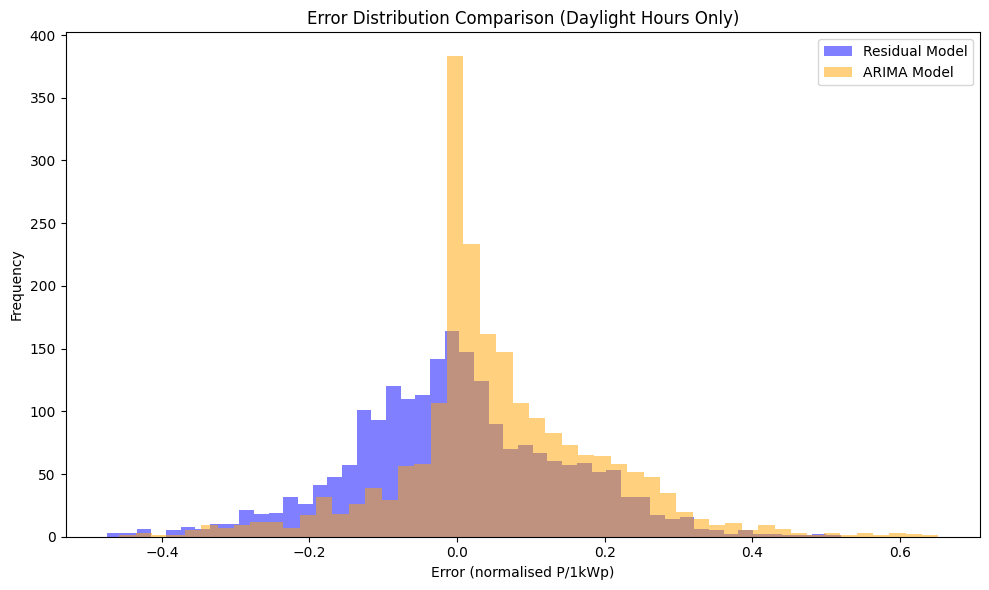

In [55]:
import matplotlib.pyplot as plt
# filter to daylight hours only
results  = pd.read_csv(f"{file_config.results_dir}/predictions_rolling_pretrained_drifted_ensemble.csv")
daylight_mask = results["daylight"] == 1

residual_errors = (
    results.loc[daylight_mask, "actual"] - 
    results.loc[daylight_mask, "corrected_median"]
)
arima_errors = (
    results.loc[daylight_mask, "actual"] - 
    results.loc[daylight_mask, "arima_pred"]
)

plt.figure(figsize=(10, 6))
plt.hist(residual_errors, bins=50, alpha=0.5, 
         color="blue", label="Residual Model")
plt.hist(arima_errors, bins=50, alpha=0.5, 
         color="orange", label="ARIMA Model")
plt.xlabel("Error (normalised P/1kWp)")
plt.ylabel("Frequency")
plt.title("Error Distribution Comparison (Daylight Hours Only)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{file_config.results_dir}/error_distribution_daylight_shaded.png", dpi=300)

mask = results["daylight"] == 1

res_var   = (results.loc[mask, "actual"] - results.loc[mask, "corrected_median"]).var()
arima_var = (results.loc[mask, "actual"] - results.loc[mask, "arima_pred"]).var()

print(f"Residual error variance: {res_var:.4f}")
print(f"ARIMA error variance:    {arima_var:.4f}")
res_bias   = (results.loc[mask, "actual"] - results.loc[mask, "corrected_median"]).mean()
arima_bias = (results.loc[mask, "actual"] - results.loc[mask, "arima_pred"]).mean()

res_rmse   = np.sqrt(((results.loc[mask, "actual"] - results.loc[mask, "corrected_median"])**2).mean())
arima_rmse = np.sqrt(((results.loc[mask, "actual"] - results.loc[mask, "arima_pred"])**2).mean())

print(f"Residual: bias={res_bias:.4f} variance={0.0150:.4f} RMSE={res_rmse:.4f}")
print(f"ARIMA:    bias={arima_bias:.4f} variance={0.0140:.4f} RMSE={arima_rmse:.4f}")

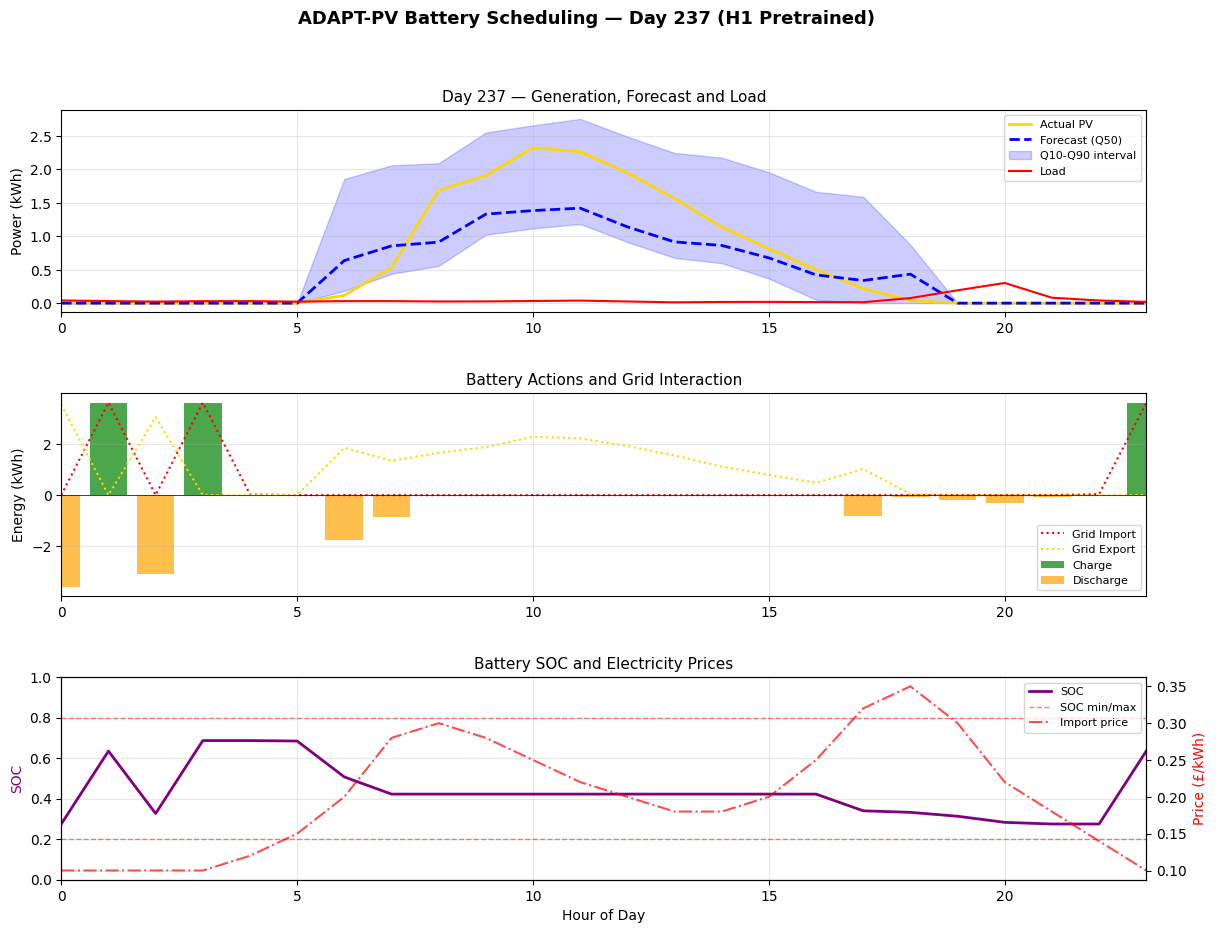

In [63]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# load your saved CSV
df = pd.read_csv(f"{file_config.results_dir}/control_tft_residual_pretrained_h1.csv")

# pick a day to visualise — try a summer day (day 180 = late June)
day = 237
mask = df["day"] == day
day_df = df[mask].reset_index(drop=True)

hours = day_df["hour"]

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.4)

# Panel 1 — Generation and Load
ax1 = fig.add_subplot(gs[0])
ax1.plot(hours, day_df["actual_pv"],       
         color="gold", linewidth=2, label="Actual PV")
ax1.plot(hours, day_df["forecast_median"], 
         color="blue", linewidth=2, linestyle="--", label="Forecast (Q50)")
ax1.fill_between(hours, 
                  day_df["forecast_lower"],
                  day_df["forecast_upper"],
                  alpha=0.2, color="blue", label="Q10-Q90 interval")
ax1.plot(hours, day_df["load"],            
         color="red", linewidth=1.5, label="Load")
ax1.set_ylabel("Power (kWh)", fontsize=10)
ax1.set_title(f"Day {day} — Generation, Forecast and Load", fontsize=11)
ax1.legend(fontsize=8)
ax1.set_xlim(0, 23)
ax1.grid(alpha=0.3)

# Panel 2 — Battery actions
ax2 = fig.add_subplot(gs[1])
ax2.bar(hours, day_df["charge"],    
        color="green", alpha=0.7, label="Charge")
ax2.bar(hours, -day_df["discharge"],
        color="orange", alpha=0.7, label="Discharge")
ax2.plot(hours, day_df["actual_import"], 
         color="red", linewidth=1.5, 
         linestyle=":", label="Grid Import")
ax2.plot(hours, day_df["actual_export"], 
         color="gold", linewidth=1.5, 
         linestyle=":", label="Grid Export")
ax2.set_ylabel("Energy (kWh)", fontsize=10)
ax2.set_title("Battery Actions and Grid Interaction", fontsize=11)
ax2.legend(fontsize=8)
ax2.set_xlim(0, 23)
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.grid(alpha=0.3)

# Panel 3 — SOC and prices
ax3 = fig.add_subplot(gs[2])
ax3_twin = ax3.twinx()

ax3.plot(hours, day_df["soc_next"],    
         color="purple", linewidth=2, label="SOC")
ax3.axhline(y=0.2, color="red", linestyle="--", 
            alpha=0.5, linewidth=1, label="SOC min/max")
ax3.axhline(y=0.8, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax3.set_ylabel("SOC", fontsize=10, color="purple")
ax3.set_ylim(0, 1)

ax3_twin.plot(hours, day_df["import_price"], 
              color="red", linewidth=1.5, 
              linestyle="-.", alpha=0.7, label="Import price")
ax3_twin.set_ylabel("Price (£/kWh)", fontsize=10, color="red")

ax3.set_xlabel("Hour of Day", fontsize=10)
ax3.set_title("Battery SOC and Electricity Prices", fontsize=11)
ax3.set_xlim(0, 23)
ax3.grid(alpha=0.3)

# combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle(f"ADAPT-PV Battery Scheduling — Day {day} (H1 Pretrained)", 
             fontsize=13, fontweight='bold')
plt.savefig(f"{file_config.results_dir}/scheduling_day_{day}_tft_residual.png", 
            dpi=300, bbox_inches='tight')
plt.show()

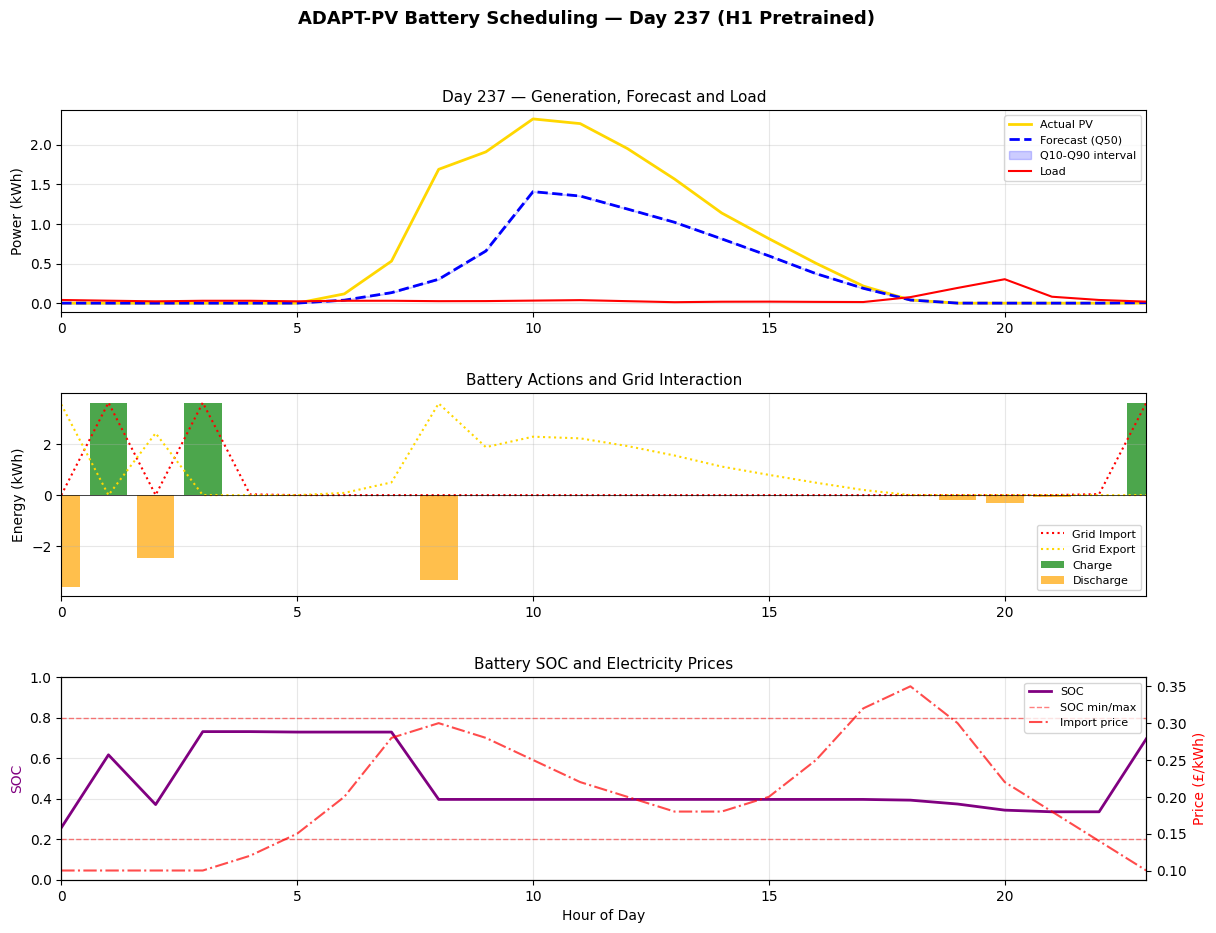

In [65]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# load your saved CSV
df = pd.read_csv(f"{file_config.results_dir}/control_arima_pretrained_h1.csv")

# pick a day to visualise — try a summer day (day 180 = late June)
day = 237
mask = df["day"] == day
day_df = df[mask].reset_index(drop=True)

hours = day_df["hour"]

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.4)

# Panel 1 — Generation and Load
ax1 = fig.add_subplot(gs[0])
ax1.plot(hours, day_df["actual_pv"],       
         color="gold", linewidth=2, label="Actual PV")
ax1.plot(hours, day_df["forecast_median"], 
         color="blue", linewidth=2, linestyle="--", label="Forecast (Q50)")
ax1.fill_between(hours, 
                  day_df["forecast_lower"],
                  day_df["forecast_upper"],
                  alpha=0.2, color="blue", label="Q10-Q90 interval")
ax1.plot(hours, day_df["load"],            
         color="red", linewidth=1.5, label="Load")
ax1.set_ylabel("Power (kWh)", fontsize=10)
ax1.set_title(f"Day {day} — Generation, Forecast and Load", fontsize=11)
ax1.legend(fontsize=8)
ax1.set_xlim(0, 23)
ax1.grid(alpha=0.3)

# Panel 2 — Battery actions
ax2 = fig.add_subplot(gs[1])
ax2.bar(hours, day_df["charge"],    
        color="green", alpha=0.7, label="Charge")
ax2.bar(hours, -day_df["discharge"],
        color="orange", alpha=0.7, label="Discharge")
ax2.plot(hours, day_df["actual_import"], 
         color="red", linewidth=1.5, 
         linestyle=":", label="Grid Import")
ax2.plot(hours, day_df["actual_export"], 
         color="gold", linewidth=1.5, 
         linestyle=":", label="Grid Export")
ax2.set_ylabel("Energy (kWh)", fontsize=10)
ax2.set_title("Battery Actions and Grid Interaction", fontsize=11)
ax2.legend(fontsize=8)
ax2.set_xlim(0, 23)
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.grid(alpha=0.3)

# Panel 3 — SOC and prices
ax3 = fig.add_subplot(gs[2])
ax3_twin = ax3.twinx()

ax3.plot(hours, day_df["soc_next"],    
         color="purple", linewidth=2, label="SOC")
ax3.axhline(y=0.2, color="red", linestyle="--", 
            alpha=0.5, linewidth=1, label="SOC min/max")
ax3.axhline(y=0.8, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax3.set_ylabel("SOC", fontsize=10, color="purple")
ax3.set_ylim(0, 1)

ax3_twin.plot(hours, day_df["import_price"], 
              color="red", linewidth=1.5, 
              linestyle="-.", alpha=0.7, label="Import price")
ax3_twin.set_ylabel("Price (£/kWh)", fontsize=10, color="red")

ax3.set_xlabel("Hour of Day", fontsize=10)
ax3.set_title("Battery SOC and Electricity Prices", fontsize=11)
ax3.set_xlim(0, 23)
ax3.grid(alpha=0.3)

# combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle(f"ADAPT-PV Battery Scheduling — Day {day} (H1 Pretrained)", 
             fontsize=13, fontweight='bold')
plt.savefig(f"{file_config.results_dir}/scheduling_day_{day}_arima.png", 
            dpi=300, bbox_inches='tight')
plt.show()

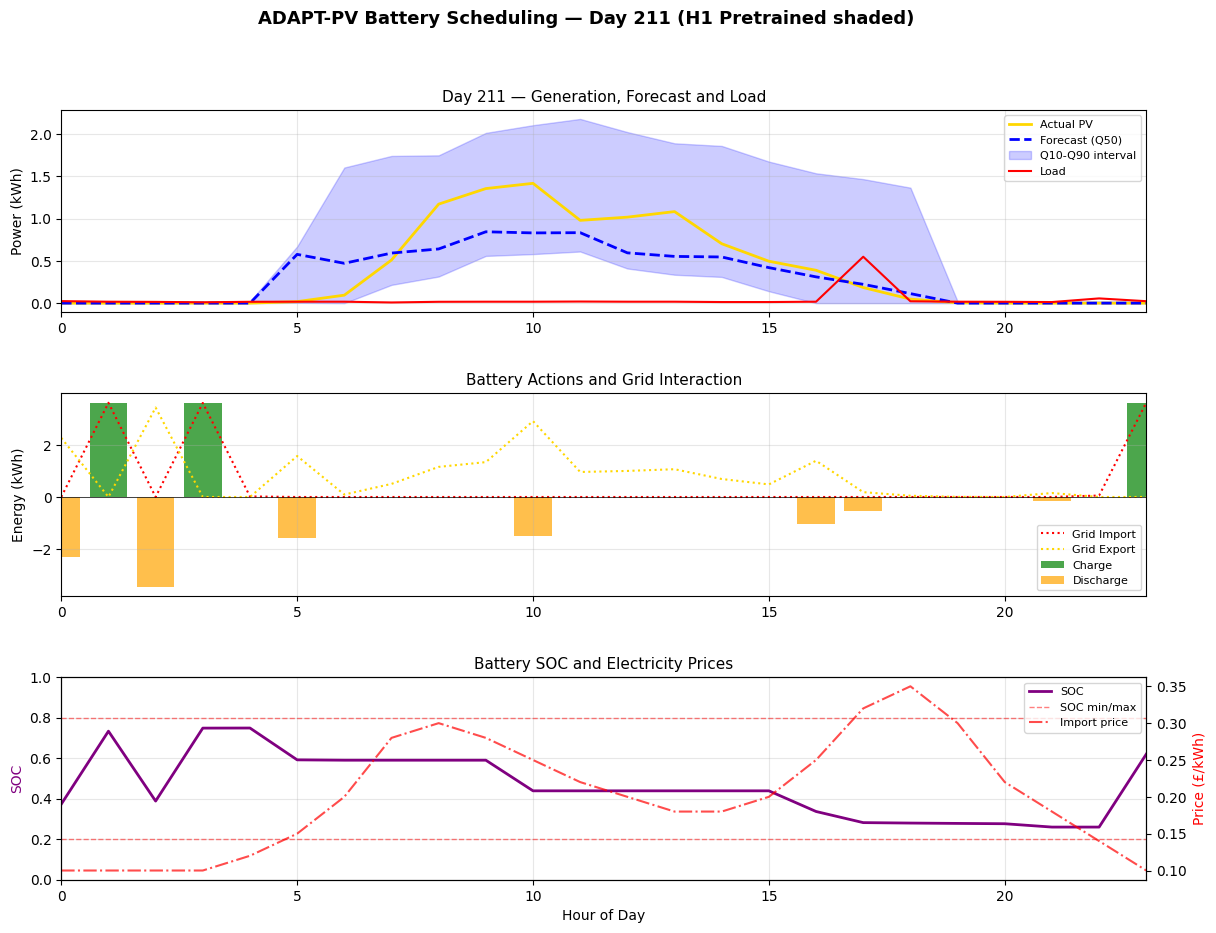

In [77]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# load your saved CSV
df = pd.read_csv(f"{file_config.results_dir}/control_tft_residual_pretrained_shaded_h1.csv")

# pick a day to visualise — try a summer day (day 180 = late June)
day = 211
mask = df["day"] == day
day_df = df[mask].reset_index(drop=True)

hours = day_df["hour"]

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.4)

# Panel 1 — Generation and Load
ax1 = fig.add_subplot(gs[0])
ax1.plot(hours, day_df["actual_pv"],       
         color="gold", linewidth=2, label="Actual PV")
ax1.plot(hours, day_df["forecast_median"], 
         color="blue", linewidth=2, linestyle="--", label="Forecast (Q50)")
ax1.fill_between(hours, 
                  day_df["forecast_lower"],
                  day_df["forecast_upper"],
                  alpha=0.2, color="blue", label="Q10-Q90 interval")
ax1.plot(hours, day_df["load"],            
         color="red", linewidth=1.5, label="Load")
ax1.set_ylabel("Power (kWh)", fontsize=10)
ax1.set_title(f"Day {day} — Generation, Forecast and Load", fontsize=11)
ax1.legend(fontsize=8)
ax1.set_xlim(0, 23)
ax1.grid(alpha=0.3)

# Panel 2 — Battery actions
ax2 = fig.add_subplot(gs[1])
ax2.bar(hours, day_df["charge"],    
        color="green", alpha=0.7, label="Charge")
ax2.bar(hours, -day_df["discharge"],
        color="orange", alpha=0.7, label="Discharge")
ax2.plot(hours, day_df["actual_import"], 
         color="red", linewidth=1.5, 
         linestyle=":", label="Grid Import")
ax2.plot(hours, day_df["actual_export"], 
         color="gold", linewidth=1.5, 
         linestyle=":", label="Grid Export")
ax2.set_ylabel("Energy (kWh)", fontsize=10)
ax2.set_title("Battery Actions and Grid Interaction", fontsize=11)
ax2.legend(fontsize=8)
ax2.set_xlim(0, 23)
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.grid(alpha=0.3)

# Panel 3 — SOC and prices
ax3 = fig.add_subplot(gs[2])
ax3_twin = ax3.twinx()

ax3.plot(hours, day_df["soc_next"],    
         color="purple", linewidth=2, label="SOC")
ax3.axhline(y=0.2, color="red", linestyle="--", 
            alpha=0.5, linewidth=1, label="SOC min/max")
ax3.axhline(y=0.8, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax3.set_ylabel("SOC", fontsize=10, color="purple")
ax3.set_ylim(0, 1)

ax3_twin.plot(hours, day_df["import_price"], 
              color="red", linewidth=1.5, 
              linestyle="-.", alpha=0.7, label="Import price")
ax3_twin.set_ylabel("Price (£/kWh)", fontsize=10, color="red")

ax3.set_xlabel("Hour of Day", fontsize=10)
ax3.set_title("Battery SOC and Electricity Prices", fontsize=11)
ax3.set_xlim(0, 23)
ax3.grid(alpha=0.3)

# combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle(f"ADAPT-PV Battery Scheduling — Day {day} (H1 Pretrained shaded)", 
             fontsize=13, fontweight='bold')
plt.savefig(f"{file_config.results_dir}/scheduling_day_{day}_tft_residual.png", 
            dpi=300, bbox_inches='tight')
plt.show()

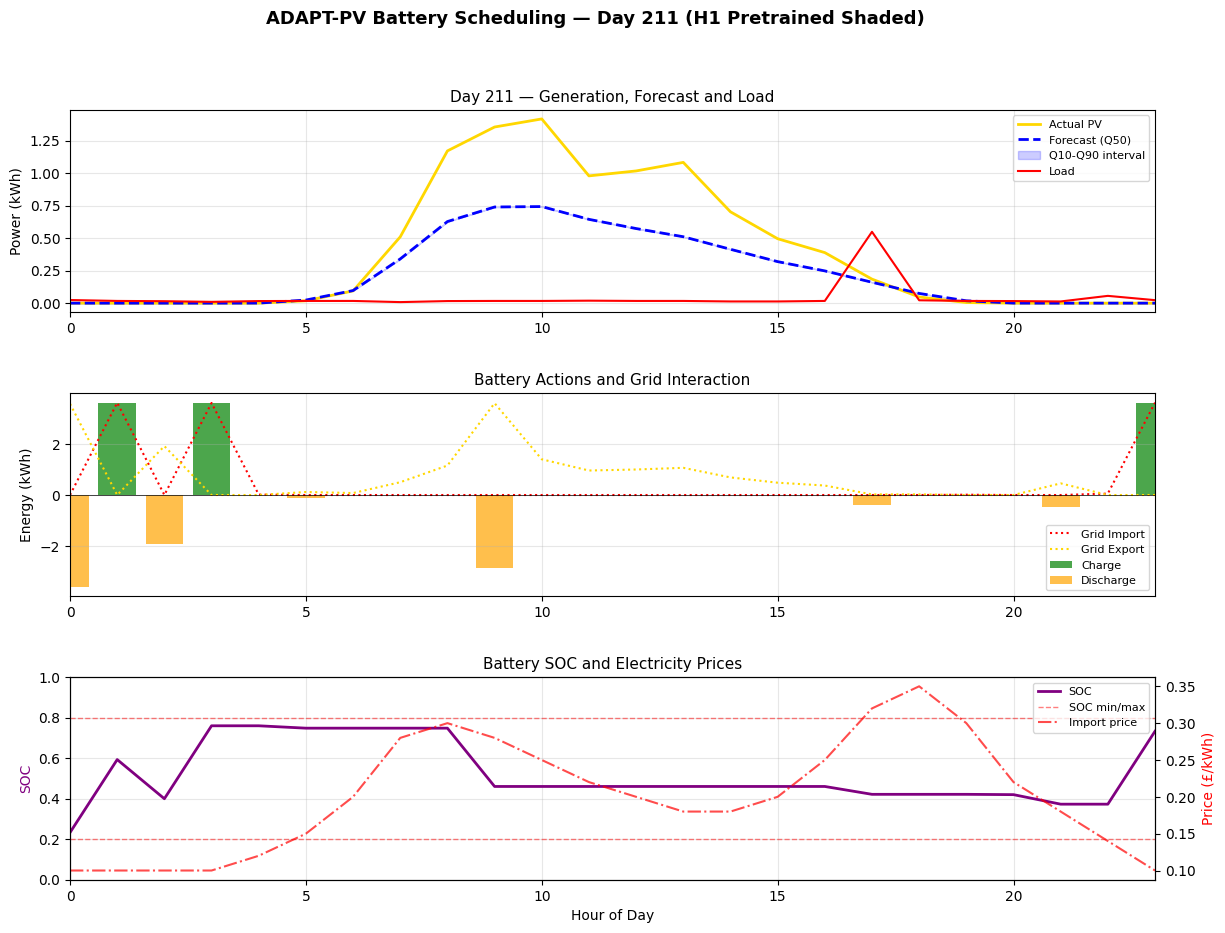

In [78]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# load your saved CSV
df = pd.read_csv(f"{file_config.results_dir}/control_arima_pretrained_shaded_h1.csv")

# pick a day to visualise — try a summer day (day 180 = late June)
day = 211
mask = df["day"] == day
day_df = df[mask].reset_index(drop=True)

hours = day_df["hour"]

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.4)

# Panel 1 — Generation and Load
ax1 = fig.add_subplot(gs[0])
ax1.plot(hours, day_df["actual_pv"],       
         color="gold", linewidth=2, label="Actual PV")
ax1.plot(hours, day_df["forecast_median"], 
         color="blue", linewidth=2, linestyle="--", label="Forecast (Q50)")
ax1.fill_between(hours, 
                  day_df["forecast_lower"],
                  day_df["forecast_upper"],
                  alpha=0.2, color="blue", label="Q10-Q90 interval")
ax1.plot(hours, day_df["load"],            
         color="red", linewidth=1.5, label="Load")
ax1.set_ylabel("Power (kWh)", fontsize=10)
ax1.set_title(f"Day {day} — Generation, Forecast and Load", fontsize=11)
ax1.legend(fontsize=8)
ax1.set_xlim(0, 23)
ax1.grid(alpha=0.3)

# Panel 2 — Battery actions
ax2 = fig.add_subplot(gs[1])
ax2.bar(hours, day_df["charge"],    
        color="green", alpha=0.7, label="Charge")
ax2.bar(hours, -day_df["discharge"],
        color="orange", alpha=0.7, label="Discharge")
ax2.plot(hours, day_df["actual_import"], 
         color="red", linewidth=1.5, 
         linestyle=":", label="Grid Import")
ax2.plot(hours, day_df["actual_export"], 
         color="gold", linewidth=1.5, 
         linestyle=":", label="Grid Export")
ax2.set_ylabel("Energy (kWh)", fontsize=10)
ax2.set_title("Battery Actions and Grid Interaction", fontsize=11)
ax2.legend(fontsize=8)
ax2.set_xlim(0, 23)
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.grid(alpha=0.3)

# Panel 3 — SOC and prices
ax3 = fig.add_subplot(gs[2])
ax3_twin = ax3.twinx()

ax3.plot(hours, day_df["soc_next"],    
         color="purple", linewidth=2, label="SOC")
ax3.axhline(y=0.2, color="red", linestyle="--", 
            alpha=0.5, linewidth=1, label="SOC min/max")
ax3.axhline(y=0.8, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax3.set_ylabel("SOC", fontsize=10, color="purple")
ax3.set_ylim(0, 1)

ax3_twin.plot(hours, day_df["import_price"], 
              color="red", linewidth=1.5, 
              linestyle="-.", alpha=0.7, label="Import price")
ax3_twin.set_ylabel("Price (£/kWh)", fontsize=10, color="red")

ax3.set_xlabel("Hour of Day", fontsize=10)
ax3.set_title("Battery SOC and Electricity Prices", fontsize=11)
ax3.set_xlim(0, 23)
ax3.grid(alpha=0.3)

# combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle(f"ADAPT-PV Battery Scheduling — Day {day} (H1 Pretrained Shaded)", 
             fontsize=13, fontweight='bold')
plt.savefig(f"{file_config.results_dir}/scheduling_day_{day}_arima_shaded.png", 
            dpi=300, bbox_inches='tight')
plt.show()

Clean mean (normalisation constant): 0.2028

Full-year NRMSE (clean):
  Naive: 0.8808
  SARIMA: 0.7656
  TFT: 0.9635
  TFT+Residual: 0.7401


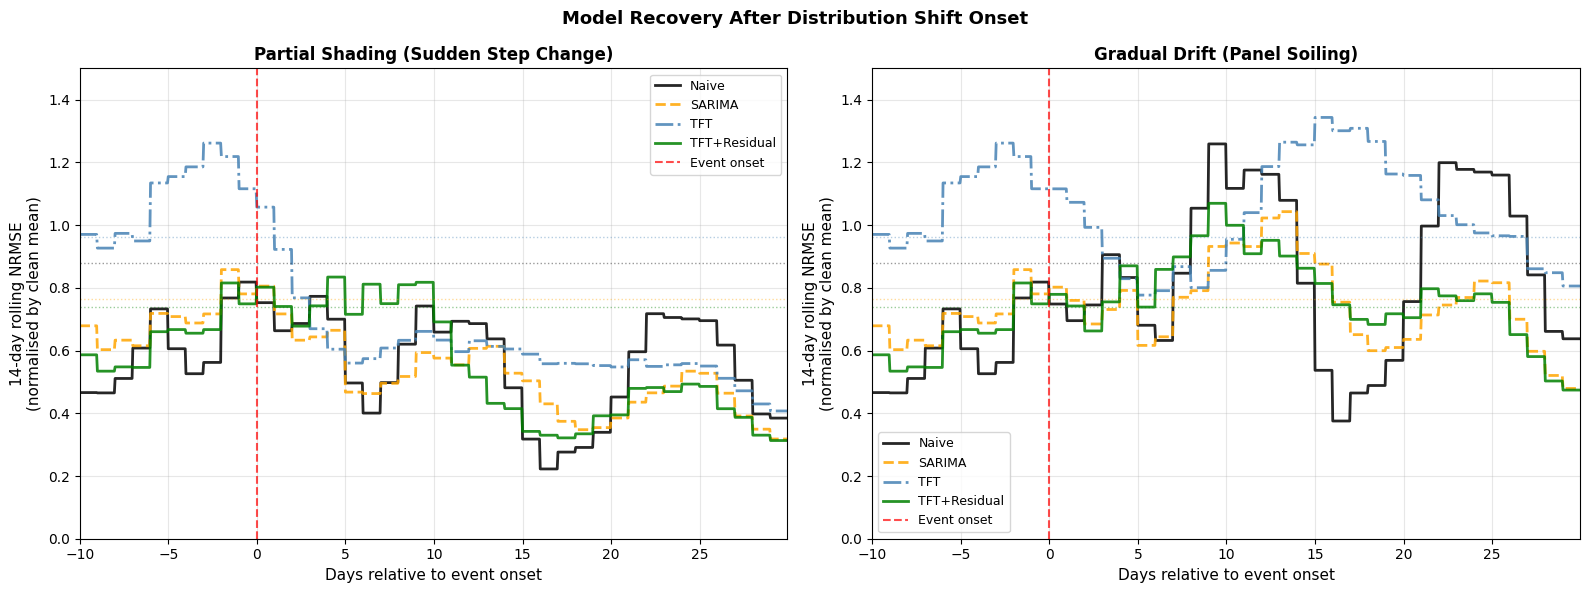

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load all condition CSVs ──────────────────────────────────────────────
clean_ens  = pd.read_csv(f"{file_config.results_dir}/predictions_rolling_pretrained_ensemble.csv")
drift_ens  = pd.read_csv(f"{file_config.results_dir}/predictions_rolling_pretrained_drifted_ensemble.csv")
shade_ens  = pd.read_csv(f"{file_config.results_dir}/predictions_rolling_pretrained_shaded_ensemble.csv")

# ── 2. Add naive prediction to all dataframes ───────────────────────────────
for df in [clean_ens, drift_ens, shade_ens]:
    df["naive_pred"] = df["actual"].shift(24)

# ── 3. Compute clean mean as normalisation constant ─────────────────────────
daylight_mask_clean = clean_ens["daylight"] == 1
clean_mean = clean_ens.loc[daylight_mask_clean, "actual"].mean()
print(f"Clean mean (normalisation constant): {clean_mean:.4f}")

# ── 4. Rolling NRMSE function ────────────────────────────────────────────────
# Rolls over real calendar days (via groupby(date)), not a fixed daylight-hours-
# per-day guess — a "7-day window" during UK summer (~16-17h daylight) is not
# the same number of samples as during winter (~8h), so rolling over raw
# daylight-only rows under- or over-smooths depending on the season.
def rolling_nrmse(df, pred_col, window_days=7, normaliser=clean_mean):
    daylight = df.loc[df["daylight"] == 1, ["time", "actual", pred_col]].copy()
    daylight["date"] = pd.to_datetime(daylight["time"]).dt.date
    daily_mse = ((daylight["actual"] - daylight[pred_col]) ** 2).groupby(daylight["date"]).mean()
    daily_nrmse = (daily_mse ** 0.5) / normaliser
    rolling_daily = daily_nrmse.rolling(window_days, min_periods=max(1, window_days // 2)).mean()

    # broadcast each day's rolling value to every row (day + night) of that day for plotting
    row_dates = pd.to_datetime(df["time"]).dt.date
    return row_dates.map(rolling_daily).astype(float)

# ── 5. Full-year NRMSE function ──────────────────────────────────────────────
def full_nrmse(df, pred_col, normaliser=clean_mean):
    mask   = df["daylight"] == 1
    errors = (df.loc[mask, "actual"] - df.loc[mask, pred_col]) ** 2
    return float((errors.mean() ** 0.5) / normaliser)

# ── 6. Define models ─────────────────────────────────────────────────────────
models = {
    "Naive":        "naive_pred",
    "SARIMA":       "arima_pred",
    "TFT":          "tft_pred",
    "TFT+Residual": "corrected_median",
}

# ── 7. Compute rolling NRMSE for all models and conditions ──────────────────
results_clean = {name: rolling_nrmse(clean_ens, col) for name, col in models.items()}
results_drift = {name: rolling_nrmse(drift_ens, col) for name, col in models.items()}
results_shade = {name: rolling_nrmse(shade_ens, col) for name, col in models.items()}

# ── 8. Compute baselines ─────────────────────────────────────────────────────
baselines = {name: full_nrmse(clean_ens, col) for name, col in models.items()}
print("\nFull-year NRMSE (clean):")
for name, val in baselines.items():
    print(f"  {name}: {val:.4f}")

# ── 9. Plot settings ──────────────────────────────────────────────────────────
colors = {
    "Naive":        "black",
    "SARIMA":       "orange",
    "TFT":          "steelblue",
    "TFT+Residual": "green",
}
linestyles = {
    "Naive":        "-",
    "SARIMA":       "--",
    "TFT":          "-.",
    "TFT+Residual": "-",
}

# ── 10. Plot window around onset ─────────────────────────────────────────────
# Derived from the data instead of hardcoded: the ensemble CSVs start on
# 2023-01-11, so June 1st is day 141 from row 0, not day 151 — a stale
# hardcoded value here previously shifted the whole plot (and the "Event
# onset" line) 10 days late, mislabeling the first 10 real days of the
# shading/drift event as pre-event baseline.
onset_date = pd.Timestamp("2023-06-01")
shade_onset_idx = int((pd.to_datetime(shade_ens["time"]) >= onset_date).idxmax())
plot_start = max(0, shade_onset_idx - 10 * 24)   # 10 days before
plot_end   = min(len(shade_ens), shade_onset_idx + 30 * 24)  # 30 days after
x_days     = (np.arange(plot_start, plot_end) - shade_onset_idx) / 24

# ── 11. Generate plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, results_dict) in zip(axes, [
    ("Partial Shading (Sudden Step Change)", results_shade),
    ("Gradual Drift (Panel Soiling)",        results_drift),
]):
    for name, rolling in results_dict.items():
        y = rolling.values[plot_start:plot_end]
        ax.plot(x_days, y,
                color=colors[name],
                linestyle=linestyles[name],
                linewidth=2,
                label=name,
                alpha=0.85)

    # baseline dashed horizontal lines
    for name, baseline in baselines.items():
        ax.axhline(y=baseline,
                   color=colors[name],
                   linestyle=":",
                   linewidth=1,
                   alpha=0.4)

    # event onset vertical line
    ax.axvline(x=0, color="red", linewidth=1.5,
               linestyle="--", alpha=0.7, label="Event onset")

    ax.set_xlabel("Days relative to event onset", fontsize=11)
    ax.set_ylabel("14-day rolling NRMSE\n(normalised by clean mean)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(x_days[0], x_days[-1])
    ax.set_ylim(0, 1.5)

plt.suptitle(
    "Model Recovery After Distribution Shift Onset",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("../results/recovery_plots_standardised.png",
            dpi=300, bbox_inches='tight')
plt.show()

Week window: 2023-09-25 00:00:00 to 2023-10-01 23:00:00 (168 hours)


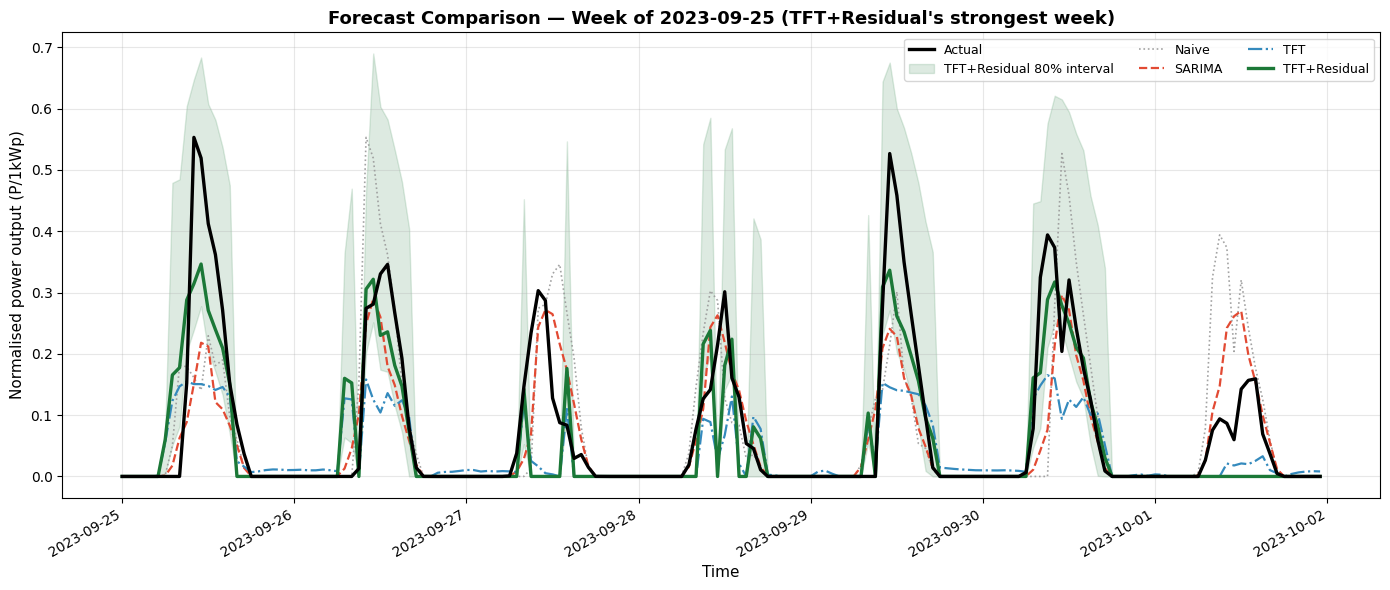

Naive          RMSE: 0.1677
SARIMA         RMSE: 0.1400
TFT            RMSE: 0.1648
TFT+Residual   RMSE: 0.1035


In [79]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Best week for showing TFT+Residual outperforming Naive/ARIMA/TFT-alone ──
# Selected by ranking all full ISO weeks (clean, house 1) on RMSE margin
# between TFT+Residual and the best of the three baselines, daylight hours
# only. Week 39 (2023-09-25 to 2023-10-01) wins on both relative margin
# (26.1% better than ARIMA, the best baseline that week) and on beating all
# three baselines simultaneously, not just edging out one.
results = pd.read_csv(f"{file_config.results_dir}/predictions_rolling_pretrained_ensemble.csv")
results["time"] = pd.to_datetime(results["time"])

week_start = pd.Timestamp("2023-09-25 00:00:00")
week_end   = pd.Timestamp("2023-10-02 00:00:00")
week = results[(results["time"] >= week_start) & (results["time"] < week_end)].reset_index(drop=True)
print(f"Week window: {week['time'].min()} to {week['time'].max()} ({len(week)} hours)")

x = week["time"]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x, week["actual"], color="#000000", linewidth=2.4, label="Actual", zorder=5)

# TFT+Residual uncertainty band
ax.fill_between(x, week["corrected_lower"], week["corrected_upper"],
                 color="#1B7837", alpha=0.15, label="TFT+Residual 80% interval")

ax.plot(x, week["naive"],            color="#999999",   linestyle=":",  linewidth=1.2, alpha=0.9, label="Naive")
ax.plot(x, week["arima_pred"],       color="#E24A33",   linestyle="--", linewidth=1.6, label="SARIMA")
ax.plot(x, week["tft_pred"],         color="#348ABD",   linestyle="-.", linewidth=1.6, label="TFT")
ax.plot(x, week["corrected_median"], color="#1B7837",   linestyle="-",  linewidth=2.4, label="TFT+Residual", zorder=4)

ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Normalised power output (P/1kWp)", fontsize=11)
ax.set_title("Forecast Comparison — Week of 2023-09-25 (TFT+Residual's strongest week)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, ncol=3, loc="upper right")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(f"{file_config.results_dir}/forecast_week_sept25_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# quick daylight-only RMSE recap for this week, for the caption/text
mask = week["daylight"] == 1
for name, col in [("Naive", "naive"), ("SARIMA", "arima_pred"), ("TFT", "tft_pred"), ("TFT+Residual", "corrected_median")]:
    rmse = ((week.loc[mask, "actual"] - week.loc[mask, col]) ** 2).mean() ** 0.5
    print(f"{name:<14} RMSE: {rmse:.4f}")